In [1]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import rosbag
from tf.transformations import euler_from_quaternion
from tqdm import tqdm


def pose2d_to_mat4(x, y, yaw):
    """
    2D pose (x, y, yaw) → 4x4 homogeneous transform (SE3)
    yaw 단위: rad
    """
    c, s = np.cos(yaw), np.sin(yaw)
    T = np.eye(4)
    T[0,0], T[0,1] = c, -s
    T[1,0], T[1,1] = s,  c
    T[0,3], T[1,3] = x, y
    return T

def mat4_to_pose2d(T):
    x, y = T[0,3], T[1,3]
    yaw = np.arctan2(T[1,0], T[0,0])
    return x, y, yaw

def T_w_c_to_T_w_o(T_w_c):
    """
    카메라 좌표계에서 오브젝트 좌표계로 변환
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    """
    # 카메라 좌표계에서 오브젝트 좌표계로의 변환 행렬 (예: 90도 회전)
    T_c_o = np.array([[0, -1, 0, 0],
                      [0, 0, -1, 0],
                      [1, 0, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 계산
    T_w_o = np.dot(T_w_c, T_c_o)
    
    return T_w_o

def T_w_o_to_T_w_c(T_w_o):
    """
    오브젝트 좌표계에서 카메라 좌표계로 변환
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    """
    # 오브젝트 좌표계에서 카메라 좌표계로의 변환 행렬 (예: -90도 회전)
    T_o_c = np.array([[0, 0, 1, 0],
                      [-1, 0, 0, 0],
                      [0, -1, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 카메라 좌표계로의 변환 행렬 계산
    T_w_c = np.dot(T_w_o, T_o_c)
    
    return T_w_c


def project_to_se2_camera(T: np.ndarray) -> np.ndarray:
    """
    임의의 SE(3) 변환 T를 카메라 좌표계(z-forward, x-right, y-down) 기준에서
    (z, x, yaw)만 남기는 4x4로 투영.
    yaw는 y축(수직축) 회전으로 정의.
    """
    # yaw 추출 (y축 회전)
    yaw = np.arctan2(T[0,2], T[2,2])  # R[0,2]/R[2,2]

    c, s = np.cos(yaw), np.sin(yaw)

    Tout = np.eye(4)
    # y축 회전 행렬 (camera convention: z-forward, x-right, y-down)
    Tout[0,0], Tout[0,2] =  c, s
    Tout[2,0], Tout[2,2] = -s, c
    Tout[1,1] = 1.0

    # 평행이동은 x(right), z(forward)만 유지, y는 그대로 두되 나중에 필요없으면 0으로
    Tout[0,3] = T[0,3]  # x
    Tout[1,3] = 0.0     # y는 무시 (수평 이동만 고려)
    Tout[2,3] = T[2,3]  # z

    return Tout


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO - 2025-10-13 19:25:53,582 - topics - topicmanager initialized


# Load rosbag data

In [2]:

# ===============================
# 1. 데이터 로드 (사용자 준비)
# ===============================
# 예시: rgb_list, depth_list, vo_poses는 미리 준비된 리스트
#  - rgb_list: (H, W, 3) numpy array
#  - depth_list: (H, W) numpy array, 사람 영역은 mask된 depth
#  - vo_poses: 각 프레임의 VO pose (4x4 numpy array)

import cv2

rgb_list = [] 
rgb_time = [] 
depth_list = []  
depth_time = [] 
vo_poses = []      # VO trajectory (각각 4x4 pose)
vo_time = []  
object_detect = []  # 각 프레임의 객체 검출 결과 (사용자 정의 형식)
object_time = []  # 객체 검출 시간 리스트
target_pose = []  # 각 프레임의 객체 검출 결과 (3D 좌표)
target_pose_time = []


# for gtsam
poses2d = []  # (x, y, yaw) 리스트
covs2d = []  # 3x3 공분산 리스트



bagfile = "/media/seungwoo/T5_JSW/rosbag_alchemist_2025_08_01/3F/6/2025-08-01-14-46-43.bag"
odom_topic = "/zed2/zed_node/odom"
depth_topic = "/zed_client/image_depth_masked"
rgb_topic = "/zed2/zed_node/rgb/image_rect_color"
obj_det_topic = "/zed2/zed_node/obj_det/objects"
target_pose_topic = "/zed_client/object1_position"


# fig, ax = plt.subplots(1, 1)
# plt.ion()
# ax.set_title("Depth Image")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# img_plot = ax.imshow(np.zeros((480, 640)), cmap='gray')
# colorbar = plt.colorbar(img_plot, ax=ax)
# plt.pause(0.1)  # 잠시 표시

with rosbag.Bag(bagfile) as bag:
    for topic, msg, t in tqdm(bag.read_messages(topics=[rgb_topic, depth_topic, odom_topic, obj_det_topic,target_pose_topic]), desc="Loading data from bag",):
        if topic == rgb_topic:
            rgb = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1).copy()
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb_list.append(rgb)
            rgb_time.append(t)
        elif topic == depth_topic:
            depth = np.frombuffer(msg.data, dtype=np.float32).reshape(msg.height, msg.width).copy()
            # img_plot.set_data(depth)
            # img_plot.set_clim(vmin=np.nanmin(depth), vmax=np.nanmax(depth))
            # plt.pause(0.001)
            depth_list.append(depth)
            depth_time.append(t)
        elif topic == odom_topic:
            
            x = msg.pose.pose.position.x
            y = msg.pose.pose.position.y
            z = 0  # 2D이므로 z=0 고정
            # orientation quaternion -> yaw
            q = msg.pose.pose.orientation
            quat = [q.x, q.y, q.z, q.w]
            roll, pitch, yaw = euler_from_quaternion(quat)
            T = pose2d_to_mat4(x, y, yaw)
            vo_poses.append(T)
            poses2d.append((x, y, yaw))
            cov = np.array(msg.pose.covariance).reshape(6,6)
            cov_2d_cur = cov[np.ix_([0,1,5],[0,1,5])]  # x, y, yaw에 해당하는 부분 추출
            covs2d.append(cov_2d_cur)
            vo_time.append(t)
        elif topic == obj_det_topic:
            object_detect.append(msg)  # 사용자 정의 형식에 맞게 저장
            object_time.append(t)
        elif topic == target_pose_topic:
            object_detect_xyz = np.array([msg.point.x, msg.point.y, msg.point.z], dtype=np.float32)
            target_pose.append(object_detect_xyz)
            target_pose_time.append(t)


# 시간 동기화 (가장 가까운 시간의 depth/rgb/vo 매칭)
synced_rgb = []
synced_depth = []
synced_vo_poses = []
synced_pose2d = []
synced_cov2d = []
synced_object_detect = []
synced_target_pose = []
for i in range(len(depth_time)):
    depth_t = depth_time[i]
    # 가장 가까운 rgb 찾기
    rgb_diffs = [abs((depth_t - rt).to_sec()) for rt in rgb_time]
    rgb_idx = np.argmin(rgb_diffs)
    # 가장 가까운 vo 찾기
    vo_diffs = [abs((depth_t - vt).to_sec()) for vt in vo_time]
    vo_idx = np.argmin(vo_diffs)
    # 가장 가까운 object detection 찾기
    obj_diffs = []
    for ot in object_time:
        if (depth_t - ot).to_sec() > 0:
            obj_diffs.append(abs((depth_t - ot).to_sec()))
        else:
            obj_diffs.append(float('inf'))
    obj_idx = np.argmin(obj_diffs)
    target_pose_diffs = []
    for tt in target_pose_time:
        if (depth_t - tt).to_sec() > 0:
            target_pose_diffs.append(abs((depth_t - tt).to_sec()))
        else:
            target_pose_diffs.append(float('inf'))
    target_idx = np.argmin(target_pose_diffs)

    # gbr = rgb_list[rgb_idx]
    # rgb = gbr.copy()
    # rgb[:,:,0] = gbr[:,:,2]
    # rgb[:,:,2] = gbr[:,:,0]
    synced_rgb.append(rgb_list[rgb_idx])
    synced_depth.append(depth_list[i])  # depth는 현재 인덱스 사용
    synced_vo_poses.append(vo_poses[vo_idx])
    synced_pose2d.append(poses2d[vo_idx])
    synced_cov2d.append(covs2d[vo_idx])
    synced_object_detect.append(object_detect[obj_idx])
    synced_target_pose.append(target_pose[target_idx])


rgb_list = synced_rgb
depth_list = synced_depth
vo_poses = synced_vo_poses
object_detect = synced_object_detect
poses2d = synced_pose2d
covs2d = synced_cov2d
vo_cam_pose = T_w_o_to_T_w_c(synced_vo_poses)  # 카메라 좌표계에서의 VO pose (4x4 numpy array)
target_pose = synced_target_pose


Loading data from bag: 2129it [00:06, 330.42it/s]


In [3]:

for i in range(len(target_pose)):
    # make relative position to camera
    tar = target_pose[i]
    cur_vo = vo_poses[i]
    tar_cam = np.linalg.inv(cur_vo) @ np.array([tar[0], tar[1], tar[2], 1.0])
    target_pose[i] = tar_cam[:3]


### trim multi man frame

In [4]:
tmp_list = np.array([len(object_detect[i].objects) for i in range(len(object_detect))])

double_man_indxes = np.where(tmp_list>1)[0]
double_man_indxes


array([242, 247, 270, 272, 273, 276, 279, 280, 333, 334, 335, 336, 337,
       338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350,
       351, 352, 353, 354, 355, 356])

In [5]:
tmp_list = [[object_detect[i].objects[j].confidence for j in range(len(object_detect[i].objects))] for i in range(len(object_detect))]
max_conf = []
for tmp in tmp_list:
    if len(tmp)>1:
        max_conf.append(max(tmp))
    else:
        max_conf.append(tmp[0])

tmp_arr = np.array(max_conf)
high_conf_inds = np.where(tmp_arr<70)[0]
high_conf_inds


array([ 85, 129, 130, 131, 301, 305])

In [6]:

for i in double_man_indxes:

    rGlobalMin = 0
    cGlobalMin = 0
    rGlobalMax = 320-1
    cGlobalMax = 640-1
    x_padding = 5
    y_padding = 0
 
    # plt.imshow(depth_list[i])
    # plt.imshow(rgb_list[i])
    for det in object_detect[i].objects:
        # if det.confidence > 70 :
        #     continue
        bound = [det.bounding_box_2d.corners[j].kp for j in range(4)]
        bound = np.array(bound, dtype=int) /2

        rMin = max(int(np.min(bound[:,1])) - y_padding, rGlobalMin)
        rMax = min(int(np.max(bound[:,1])) + y_padding, rGlobalMax)
        cMin = max(int(np.min(bound[:,0])) - x_padding, cGlobalMin)
        cMax = min(int(np.max(bound[:,0])) + x_padding, cGlobalMax)
        depth_list[i][rMin:rMax, cMin:cMax] = np.nan
        # plt.plot([cMin, cMax, cMax, cMin, cMin], [rMin, rMin, rMax, rMax, rMin], 'r-')
        # print(det.confidence)
    # plt.show()
    # break
    

## PCL정제 

In [7]:
# ===============================
# 2. point cloud 정제
# ===============================
import copy


visualize = True
start_frame = 0
end_frame = len(depth_list)
# start_frame = 270
# end_frame = 280
# frame_step = 1  # 몇 프레임마다 처리할지 (속도 조절용)

voxel_size = 0.05  # point cloud downsample voxel size (m)
depth_trunc = 4.5  # 사용할 depth 범위 (m)

statistical_outlier_removal = True
# 통계적 이상치
if statistical_outlier_removal:
    nb_neighbors = 100  # 통계적 이상치 제거 이웃 개수
    std_ratio = 0.01  # 통계적 이상치 제거 표준편차 배수
# 반경기반 이상치
else:
    nb_points = 16  # 반경 기반 이상치 제거 이웃 개수
    radius = 0.3  # 반경 기반 이상치 제거 반경 (m)

# yaw_only = True  # 최적화의 yaw만 사용

# z -> -y axis
z_min = -0.5
z_max = 0.3

max_range = 3.0  # pcl max range from camera

refined_poses = [vo_cam_pose[start_frame]]
reg_list = []
prev_idx = start_frame

fx=261.167
fy=261.167
cx=323.5188
cy=179.9977
width, height = 640, 360
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)

if visualize:
    pcl_list = []
    coords_list = []


# 첫 번째 프레임으로 prev_pcd 초기화
rgb_o3d = o3d.geometry.Image(rgb_list[start_frame].astype(np.uint8))
depth_o3d = o3d.geometry.Image(depth_list[start_frame].astype(np.float32))
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
    convert_rgb_to_intensity=False
)
prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
prev_pcd = prev_pcd.voxel_down_sample(voxel_size)
prev_pcd = prev_pcd.select_by_index(np.where((np.asarray(prev_pcd.points)[:,1] > z_min) & (np.asarray(prev_pcd.points)[:,1] < z_max))[0])
prev_pcd = prev_pcd.select_by_index(np.where(np.linalg.norm(np.asarray(prev_pcd.points), axis=1) < max_range)[0])
if statistical_outlier_removal:
    prev_pcd = prev_pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]
else:
    prev_pcd = prev_pcd.remove_radius_outlier(nb_points=nb_points, radius=radius)[0]

if visualize:
    coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    coords.transform(vo_cam_pose[start_frame])

    coords_list.append(coords)
    pcl_tmp = copy.deepcopy(prev_pcd)
    pcl_tmp.transform(vo_cam_pose[start_frame]) ##???
    pcl_list.append(pcl_tmp)

for i in range(start_frame+1,end_frame):
    
    # RGBD 변환
    cur_idx = i
    rgb_o3d   = o3d.geometry.Image(rgb_list[cur_idx].astype(np.uint8))
    depth_o3d = o3d.geometry.Image((depth_list[cur_idx]).astype(np.float32))

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )

    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
    pcd = pcd.voxel_down_sample(voxel_size)
    pcd = pcd.select_by_index(np.where((np.asarray(pcd.points)[:,1] > z_min) & (np.asarray(pcd.points)[:,1] < z_max))[0])
    pcd = pcd.select_by_index(np.where(np.linalg.norm(np.asarray(pcd.points), axis=1) < max_range)[0])
    if statistical_outlier_removal:
        pcd = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]
    else:
        pcd = pcd.remove_radius_outlier(nb_points=nb_points, radius=radius)[0]

    if visualize:
        coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord.transform(vo_cam_pose[cur_idx])
        coords_list.append(coord)
        pcl_tmp = copy.deepcopy(pcd)
        pcl_tmp.transform(vo_cam_pose[cur_idx])
        pcl_list.append(pcl_tmp)
    
    
    T_refined = vo_cam_pose[cur_idx]  # 일단 VO trajectory 사용
    refined_poses.append(T_refined)
    # reg_list.append(reg)
    # print(f"Frame {cur_idx}: ICP inlier RMSE = {reg.inlier_rmse}")

    if visualize:
        pcd_tmp = copy.deepcopy(pcd)
        pcd_tmp.transform(T_refined) 
        coord_after = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord_after.transform(T_refined)

    # keyframe 업데이트
    prev_pcd = pcd
    prev_idx = cur_idx

# print("Average residual:", np.mean(residual))

if visualize:
    # visulize results
    origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    o3d.visualization.draw_geometries([origin, *coords_list, *pcl_list])


In [8]:
if visualize:
    # visulize results
    start= 300
    end = 350
    
    origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    o3d.visualization.draw_geometries([origin, *coords_list[start:end], *pcl_list[start:end]])
    # o3d.visualization.draw_geometries([*coords_after_list[start:end], *pcl_after_list[start:end]])
    # o3d.visualization.draw_geometries([*coords_after_list, *pcl_after_list])

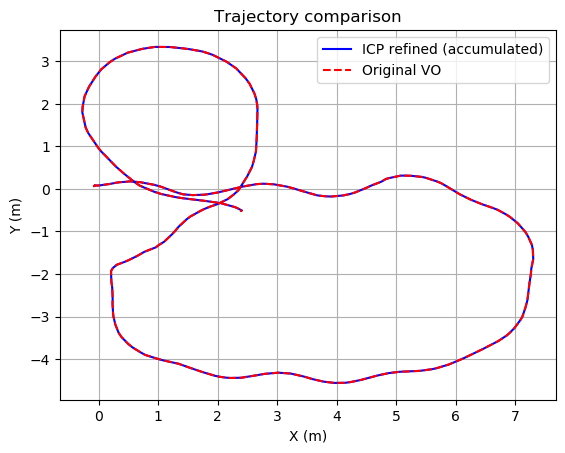

In [9]:

plt.figure()
refined_x = [T[0,3] for T in refined_poses]
refined_y = [T[1,3] for T in refined_poses]
refined_yaw = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses]
original_x = [T[0,3] for T in vo_cam_pose[start_frame:end_frame]]
original_y = [T[1,3] for T in vo_cam_pose[start_frame:end_frame]]
original_yaw = [np.arctan2(T[0,2], T[2,2]) for T in vo_cam_pose[start_frame:end_frame]]
plt.plot(refined_x, refined_y, 'b-', label='ICP refined (accumulated)')
plt.plot(original_x, original_y, 'r--', label='Original VO')
plt.title("Trajectory comparison")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()


## OCTOMAP

In [10]:
import math
from typing import Dict, Tuple, Iterable, Optional
import numpy as np

# --------- 유틸: 확률 <-> 로그오즈 ----------
def logit(p: float) -> float:
    p = np.clip(p, 1e-6, 1.0 - 1e-6)
    return float(np.log(p / (1.0 - p)))

def inv_logit(l: float) -> float:
    return 1.0 / (1.0 + np.exp(-l))

# ============================================================
# IncrementalVoxelMapper: OctoMap-like sparse voxel mapping
# ============================================================
class IncrementalVoxelMapper:
    """
    Sparse 3D occupancy mapping with log-odds updates and 3D DDA raycasting.
    - resolution: voxel size (m)
    - l_occ / l_free: log-odds increments for hit / miss (free)
    - l_min / l_max: clamping of log-odds
    - occ_threshold: cells with log-odds > threshold are considered occupied
    """
    def __init__(
        self,
        resolution: float = 0.1,
        p_hit: float = 0.7,
        p_miss: float = 0.4,
        l_min: float = -5.0,
        l_max: float = 5.0,
        occ_threshold: float = 0.0,
    ):
        assert resolution > 0
        self.res = float(resolution)
        self.l_occ = logit(p_hit)
        self.l_free = -abs(logit(1.0 - p_miss))  # miss는 음수(감소)
        self.l_min = float(l_min)
        self.l_max = float(l_max)
        self.occ_threshold = float(occ_threshold)

        # sparse grid: key=(ix,iy,iz) -> log-odds value
        self.grid: Dict[Tuple[int, int, int], float] = {}

    # ---------- 좌표 변환 ----------
    def world_to_grid(self, xyz: np.ndarray) -> Tuple[int, int, int]:
        return tuple(np.floor(xyz / self.res).astype(int))  # (ix, iy, iz)

    def grid_to_world(self, idx: Tuple[int, int, int]) -> np.ndarray:
        # voxel center 좌표
        return (np.array(idx, dtype=float) + 0.5) * self.res

    # ---------- 조회 ----------
    def get_logodds(self, idx: Tuple[int, int, int]) -> float:
        return self.grid.get(idx, 0.0)

    def set_logodds(self, idx: Tuple[int, int, int], lval: float):
        if lval == 0.0:
            self.grid.pop(idx, None)
        else:
            self.grid[idx] = float(np.clip(lval, self.l_min, self.l_max))

    def add_logodds(self, idx: Tuple[int, int, int], delta: float):
        l = self.grid.get(idx, 0.0) + delta
        self.set_logodds(idx, l)

    def is_occupied(self, idx: Tuple[int, int, int]) -> bool:
        return self.get_logodds(idx) > self.occ_threshold

    # ---------- 핵심: 포즈 + 포인트클라우드 통합 ----------
    def update_from_scan(
        self,
        T_W_C: np.ndarray,
        points_C: np.ndarray,
        max_range: Optional[float] = None,
        downsample: int = 1,
        valid_mask: Optional[np.ndarray] = None,
        is_world_frame: bool = False,
    ):
        """
        T_W_C: (4,4) 카메라(또는 라이다) 센서 포즈 (world←camera)
        points_C: (N,3) 센서 좌표계의 포인트들
        max_range: 레이 최대 길이(m). None이면 무제한
        downsample: 1 이상 정수. >1이면 간단히 포인트 다운샘플
        valid_mask: 유효 포인트만 True인 마스크(옵션)
        """
        assert T_W_C.shape == (4, 4)
        assert points_C.ndim == 2 and points_C.shape[1] == 3

        # 샘플 수 줄이기
        if downsample > 1:
            points_C = points_C[::downsample]
            if valid_mask is not None:
                valid_mask = valid_mask[::downsample]

        # 유효 포인트 필터
        if valid_mask is not None:
            points_C = points_C[valid_mask]

        if is_world_frame:
            points_W = points_C
        else:
            # 동차변환으로 월드 좌표로 변환
            ones = np.ones((points_C.shape[0], 1), dtype=points_C.dtype)
            points_C_h = np.hstack([points_C, ones])
            points_W = (T_W_C @ points_C_h.T).T[:, :3]

        origin_W = T_W_C[:3, 3].copy()

        # 각 포인트에 대해 레이캐스팅 (빈공간 감소, 끝점 증가)
        for pW in points_W:
            ray_vec = pW - origin_W
            dist = float(np.linalg.norm(ray_vec))

            if dist < 1e-6:
                continue

            # 최대 거리 제한
            hit_point = pW
            hit_is_capped = False
            if max_range is not None and dist > max_range:
                hit_point = origin_W + ray_vec * (max_range / dist)
                hit_is_capped = True

            # 1) 원점→(히트포인트 - eps) 까지 free 업데이트
            self._raycast_free(origin_W, hit_point, max_range)

            # 2) 끝점 셀은 occupied 업데이트 (단, 최대거리 캡이면 히트가 아님)
            if not hit_is_capped:
                end_idx = self.world_to_grid(hit_point)
                self.add_logodds(end_idx, self.l_occ)

    # ---------- 3D DDA로 free 업데이트 ----------
    def _raycast_free(self, start_W: np.ndarray, end_W: np.ndarray, max_range: Optional[float] = None):
        """
        Amanatides & Woo (1987) 스타일의 3D DDA.
        end 셀은 포함하지 않고 free만 업데이트.
        """
        res = self.res

        # 시작/끝 인덱스
        start_idx = np.floor(start_W / res).astype(int)
        end_idx = np.floor(end_W / res).astype(int)

        ix, iy, iz = start_idx.tolist()
        ex, ey, ez = end_idx.tolist()

        # 방향
        ray = end_W - start_W
        if np.allclose(ray, 0):
            return
        dirx, diry, dirz = ray / np.linalg.norm(ray)

        step_x = 1 if dirx > 0 else -1
        step_y = 1 if diry > 0 else -1
        step_z = 1 if dirz > 0 else -1

        # 다음 voxel 경계까지의 t
        def int_bound(s, ds, i, step):
            # 현재 voxel 경계(좌/우)까지의 거리 비율 t
            if ds == 0:
                return math.inf
            # 현재 voxel의 최소/최대 경계 좌표
            voxel_border = (i + (1 if step > 0 else 0)) * res
            return (voxel_border - s) / ds

        tx = int_bound(start_W[0], dirx, ix, step_x)
        ty = int_bound(start_W[1], diry, iy, step_y)
        tz = int_bound(start_W[2], dirz, iz, step_z)

        # 축 방향으로 한 voxel 넘어갈 때 증가하는 t
        tdx = (res / abs(dirx)) if dirx != 0 else math.inf
        tdy = (res / abs(diry)) if diry != 0 else math.inf
        tdz = (res / abs(dirz)) if dirz != 0 else math.inf

        # 레이 길이
        max_t = np.linalg.norm(end_W - start_W) / np.linalg.norm(ray) # 1.0
        ray_length = np.linalg.norm(ray)

        # 시작 셀부터 진행 (끝 셀 제외)
        # start_idx와 end_idx가 같아도 end 제외 규칙으로 free 업데이트 없음
        while (ix, iy, iz) != (ex, ey, ez):
            # 현재 셀 free 업데이트
            # max range 근처면 감소량 조절
            # if max_range is None or ray_length < max_range:
            #     self.add_logodds((ix, iy, iz), self.l_free)
            # else:
            #     # max range 근처면 감소량 선형 감소
            #     tx_rel = (tx * np.linalg.norm(ray)) / ray_length  # 현재 위치까지의 거리 비율
            #     if tx_rel < max_range:
            #         free_scale = (max_range - tx_rel) / max_range
            #         self.add_logodds((ix, iy, iz), self.l_free * free_scale)
            #     else:
            #         break

            self.add_logodds((ix, iy, iz), self.l_free)

            # 다음 셀로 진행
            if tx < ty and tx < tz:
                if tx > max_t:  # end를 넘어섬
                    break
                ix += step_x
                tx += tdx
            elif ty < tz:
                if ty > max_t:
                    break
                iy += step_y
                ty += tdy
            else:
                if tz > max_t:
                    break
                iz += step_z
                tz += tdz

    # ---------- 결과 조회/Export ----------
    def get_occupied_voxels(self) -> Iterable[Tuple[Tuple[int,int,int], float]]:
        for k, l in self.grid.items():
            if l > self.occ_threshold:
                yield (k, l)

    def get_free_voxels(self) -> Iterable[Tuple[Tuple[int,int,int], float]]:
        for k, l in self.grid.items():
            if l <= self.occ_threshold and l < 0:
                yield (k, l)

    def get_occupied_points(self) -> np.ndarray:
        pts = []
        for (idx, _) in self.get_occupied_voxels():
            pts.append(self.grid_to_world(idx))
        return np.array(pts, dtype=float) if pts else np.zeros((0,3), dtype=float)

    def get_probability(self, idx: Tuple[int,int,int]) -> float:
        return float(inv_logit(self.get_logodds(idx)))

    def slice_xy(self, z: float, size: int = 200, center: Optional[np.ndarray] = None) -> np.ndarray:
        """
        간단한 시각화용 XY 슬라이스 (확률 맵 0~1).
        size: 출력 해상도 (size x size)
        center: [x,y] 월드 좌표를 중심으로 표시 (None이면 (0,0))
        """
        if center is None:
            center = np.zeros(2)
        half = size // 2
        out = np.full((size, size), 0.5, dtype=float)
        z_idx = int(np.floor(z / self.res))

        for iy in range(size):
            for ix in range(size):
                xw = (ix - half) * self.res + center[0]
                yw = (iy - half) * self.res + center[1]
                idx = (int(np.floor(xw / self.res)), int(np.floor(yw / self.res)), z_idx)
                l = self.get_logodds(idx)
                out[iy, ix] = inv_logit(l)
        return out

    def to_open3d_geometry(self):
        """
        (옵션) Open3D가 설치되어 있으면 점군으로 변환
        occupied만 회색 점으로 반환
        """
        try:
            import open3d as o3d
        except ImportError:
            return None

        pts = self.get_occupied_points()
        if pts.shape[0] == 0:
            return o3d.geometry.PointCloud()
        pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pts))
        return pcd
    
    def update_from_world(
        self,
        T_W_C: np.ndarray,
        points_W: np.ndarray,
        max_range: Optional[float] = None,
        downsample: int = 1,
        valid_mask: Optional[np.ndarray] = None,
    ):
        """
        월드 좌표계 기준 포인트클라우드를 직접 업데이트.
        - T_W_C: (4,4) 카메라 포즈 (world←camera), 레이 원점을 얻기 위해 사용
        - points_W: (N,3) 월드 좌표계 포인트들
        """
        assert T_W_C.shape == (4, 4)
        assert points_W.ndim == 2 and points_W.shape[1] == 3

        # 다운샘플/마스크
        pts = points_W if downsample <= 1 else points_W[::downsample]
        if valid_mask is not None:
            pts = pts[valid_mask if downsample <= 1 else valid_mask[::downsample]]

        origin_W = T_W_C[:3, 3].copy()

        for pW in pts:
            ray_vec = pW - origin_W
            dist = float(np.linalg.norm(ray_vec))
            if dist < 1e-6:
                continue

            hit_point = pW
            hit_is_capped = False
            if max_range is not None and dist > max_range:
                hit_point = origin_W + ray_vec * (max_range / dist)
                hit_is_capped = True

            # 빈 공간 업데이트
            self._raycast_free(origin_W, hit_point)

            # 끝점(히트) 업데이트 (max_range로 잘린 경우 생략)
            if not hit_is_capped:
                end_idx = self.world_to_grid(hit_point)
                self.add_logodds(end_idx, self.l_occ)


In [11]:
mapper = IncrementalVoxelMapper(
    resolution=0.1,   # 10cm 보셀
    p_hit=0.7,        # 히트 시 증가 폭
    p_miss=0.4,       # 빈 공간 관측 시 감소 폭
    l_min=-5.0, l_max=5.0,
    occ_threshold=0.0 # 0보다 크면 occupied로 간주 (~확률 0.5 초과)
)

def make_T(R=np.eye(3), t=np.zeros(3)):
    T = np.eye(4)
    T[:3,:3] = R
    T[:3, 3] = t
    return T

# --- 예시: 시점 k의 카메라 포즈 (월드←카메라) ---
# 카메라가 (0,0,1.0)m 위치, 회전은 항등
# T_W_C_k = make_T(np.eye(3), np.array([0.0, 0.0, 1.0]))

# --- 예시: 그 시점의 포인트클라우드 (이미 월드 좌표계) ---
# 카메라 앞 쪽에 있는 벽/물체를 가정한 랜덤 포인트들 (z≈1.0에서 z방향 +x 전방)
# N = 8000
# x: 1.5~3.0m 앞, y: -1~1m, z: 0.2~1.8m 범위의 월드 좌표 포인트
# points_W_k = np.column_stack([
#     np.random.uniform(1.5, 3.0, size=N),
#     np.random.uniform(-1.0, 1.0, size=N),
#     np.random.uniform(0.2, 1.8, size=N),
# ])

# --- 업데이트: 월드 포인트 직접 사용 ---
# mapper.update_from_world(T_W_C_k, points_W_k, max_range=3.5, downsample=2)

# --- 다음 프레임 k+1: 카메라가 약간 이동/회전했고,
#     이전에 점유로 잘못 본 영역을 이번에 빈공간으로 많이 본다고 가정 ---
# 카메라를 x로 0.2m 이동, 약간의 yaw 회전
# yaw = np.deg2rad(5.0)
# Rz = np.array([
#     [np.cos(yaw), -np.sin(yaw), 0.0],
#     [np.sin(yaw),  np.cos(yaw), 0.0],
#     [0.0,          0.0,         1.0],
# ])
# T_W_C_k1 = make_T(Rz, np.array([0.2, 0.0, 1.0]))

# 이번에는 같은 공간을 스캔하되, 표면이 실제보다 뒤에 있다고 잘못 인식했던 포인트들이
# 빈공간으로 관측되도록 일부 포인트를 '조금 더 멀리' 이동시켜서 히트가 안 나게 구성
# (실제로는 센서가 끝점보다 짧은 max_range로 자르거나 레이가 빈 공간만 지나가게 되는 상황)
# points_W_k1 = points_W_k.copy()
# points_W_k1[:, 0] += 0.5  # x방향으로 0.5m 뒤쪽으로 밀어 히트가 줄고 free가 많아지게


for i in range(len(refined_poses)):
    T_W_C_k1 = refined_poses[i]
    points_W_k1 = np.asarray(pcl_list[i].points)
    # 업데이트
    mapper.update_from_scan(T_W_C_k1, points_W_k1, max_range=3.0, downsample=0, is_world_frame=True)

# --- 결과 확인: 점유 보셀 수/예시 좌표 ---
occupied_points_W = mapper.get_occupied_points()
print("Occupied voxels:", occupied_points_W.shape[0])
if occupied_points_W.shape[0] > 0:
    print("Sample occupied voxel center (first 5):\n", occupied_points_W[:5])


Occupied voxels: 6869
Sample occupied voxel center (first 5):
 [[ 1.45  1.95  0.35]
 [ 1.35  1.95  0.35]
 [ 1.55  1.95 -0.05]
 [ 1.45  1.85 -0.05]
 [ 1.55  1.95 -0.15]]


In [12]:

# --- (옵션) Open3D 시각화 ---
mapper.occ_threshold = logit(0.80)  # 확률 ~이상을 점유로 간주
pcd = mapper.to_open3d_geometry()
if pcd is not None:
    import open3d as o3d
    pcd = pcd.remove_radius_outlier(nb_points=30, radius=0.3)[0]
    o3d.visualization.draw_geometries([pcd])

pcd_octomap = pcd


# --- (옵션) 2D 슬라이스 확인 (z=1.0 근처)
# prob_map = mapper.slice_xy(z=1.0, size=200, center=np.array([1.5, 0.0]))
# print("Slice prob map shape:", prob_map.shape)

#### target pose

In [13]:
target_pose_refined = []
for i in range(len(target_pose)):
    P_c_t = [-target_pose[i][1], -target_pose[i][2], target_pose[i][0]]  # 카메라 좌표계 (Z, -X, -Y)
    P_w_t = refined_poses[i] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
    target_pose_refined.append((P_w_t[0], P_w_t[1], P_w_t[2]))


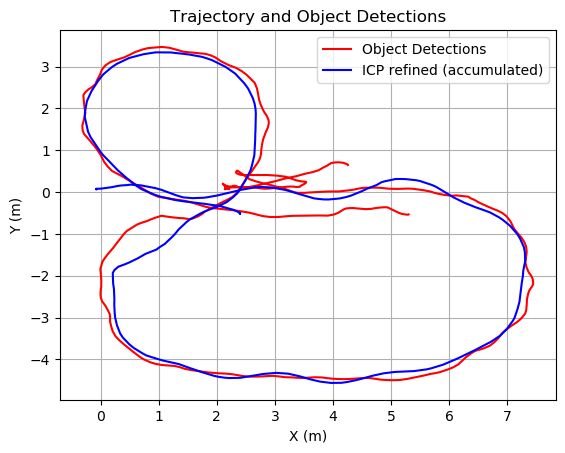

In [14]:
target_pose_x = [p[0] for p in target_pose_refined]
target_pose_y = [p[1] for p in target_pose_refined]

start = 0
end = len(target_pose_x)

plt.figure()
plt.plot(target_pose_x[start:end], target_pose_y[start:end], 'r-', label='Object Detections')
plt.plot(refined_x[start:end], refined_y[start:end], 'b-', label='ICP refined (accumulated)')
plt.title("Trajectory and Object Detections")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()

## Plotting


In [16]:
# z cliping
# z_low = -0.5
# z_high = 0.5

# test_pcl = pcl_after_list[500]
# points = np.asarray(test_pcl.points)

# valid_indices = np.where((points[:,2] >= z_low) & (points[:,2] <= z_high))[0]
# clipped_pcl = test_pcl.select_by_index(valid_indices)

# o3d.visualization.draw_geometries([clipped_pcl])

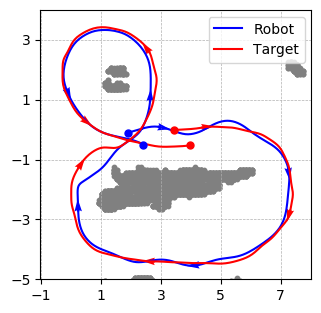

In [15]:


pcl_2d = np.array(pcd_octomap.points)

########## target, agent traj ###########
start = 110
end = len(refined_poses) - 20


refined_x = [T[0,3] for T in refined_poses[start:end]]
refined_y = [T[1,3] for T in refined_poses[start:end]]

target_pose_x = [p[0] for p in target_pose_refined[start:end]]
target_pose_y = [p[1] for p in target_pose_refined[start:end]]

# smoothing
from scipy.ndimage import gaussian_filter1d
refined_x = gaussian_filter1d(refined_x, sigma=2)
refined_y = gaussian_filter1d(refined_y, sigma=2)

target_pose_x = gaussian_filter1d(target_pose_x, sigma=2)
target_pose_y = gaussian_filter1d(target_pose_y, sigma=2)

########## rotate for better view
angle = np.deg2rad(0)
cos_a = np.cos(angle)
sin_a = np.sin(angle)
refined_x_rot = cos_a * np.array(refined_x) - sin_a * np.array(refined_y)
refined_y_rot = sin_a * np.array(refined_x) + cos_a * np.array(refined_y)
# refined_x = refined_x_rot
# refined_y = refined_y_rot
target_pose_x_rot = cos_a * np.array(target_pose_x) - sin_a * np.array(target_pose_y)
target_pose_y_rot = sin_a * np.array(target_pose_x) + cos_a * np.array(target_pose_y)
# target_pose_x = target_pose_x_rot
# target_pose_y = target_pose_y_rot
pcl_2d_rot = np.zeros_like(pcl_2d)
pcl_2d_rot[:,0] = cos_a * pcl_2d[:,0] - sin_a * pcl_2d[:,1]
pcl_2d_rot[:,1] = sin_a * pcl_2d[:,0] + cos_a * pcl_2d[:,1]
pcl_2d_rot[:,2] = pcl_2d[:,2]

############# FINAL PLOT #############

plt.figure(figsize=(3.5, 3.5))
plt.axis('equal')
plt.xlim(-1, 8)
plt.ylim(-5, 4)
plt.grid()

plt.plot(refined_x_rot, refined_y_rot, 'b-', label='Robot')
plt.plot(target_pose_x_rot, target_pose_y_rot, 'r-', markersize=2, label='Target')
# color with height
# z_min = np.min(pcl_2d[:,2])
# z_max = np.max(pcl_2d[:,2])
# color_map = plt.get_cmap('jet')
# colors = color_map((pcl_2d[:,2] - z_min) / (z_max - z_min))
# sc = plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c=colors, alpha=0.5)
plt.scatter(pcl_2d_rot[:,0], pcl_2d_rot[:,1], s=10, c='gray', alpha=1)

# indicate start and end
plt.plot(refined_x_rot[0], refined_y_rot[0], 'bo', markersize=5)
plt.plot(refined_x_rot[-1], refined_y_rot[-1], 'bo', markersize=5)

plt.plot(target_pose_x_rot[0], target_pose_y_rot[0], 'ro', markersize=5)
plt.plot(target_pose_x_rot[-1], target_pose_y_rot[-1], 'ro', markersize=5)

# plot arrow for direction
arrow_interval = 50
for i in range(10, len(refined_x_rot), arrow_interval):
    if i + 1 < len(refined_x_rot):
        dir = np.array([refined_x_rot[i+3]-refined_x_rot[i], refined_y_rot[i+3]-refined_y_rot[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(refined_x_rot[i], refined_y_rot[i], dir[0], dir[1],
                    scale=8, scale_units='inches', width=0.01, color='b')
for i in range(10, len(target_pose_x_rot), arrow_interval):
    if i + 1 < len(target_pose_x_rot):
        dir = np.array([target_pose_x_rot[i+3]-target_pose_x_rot[i], target_pose_y_rot[i+3]-target_pose_y_rot[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(target_pose_x_rot[i], target_pose_y_rot[i], dir[0], dir[1],
                     scale=8, scale_units='inches', width=0.01, color='r')

# plt.xlabel("X (m)")
# plt.ylabel("Y (m)")
# x grid every 2m
plt.xticks(np.arange(-1, 9, 2))
plt.yticks(np.arange(-5, 5, 2))
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.savefig("3F.pdf", bbox_inches='tight', dpi=300)



Mean depth dt: 0.12597547573333334
Max agent velocity: 1.2424462947486774
Max target velocity: 1.2385789518378338


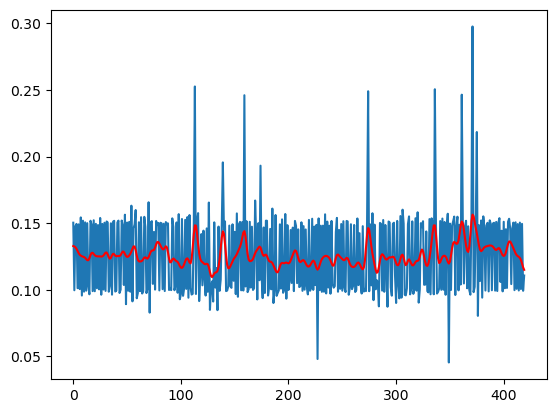

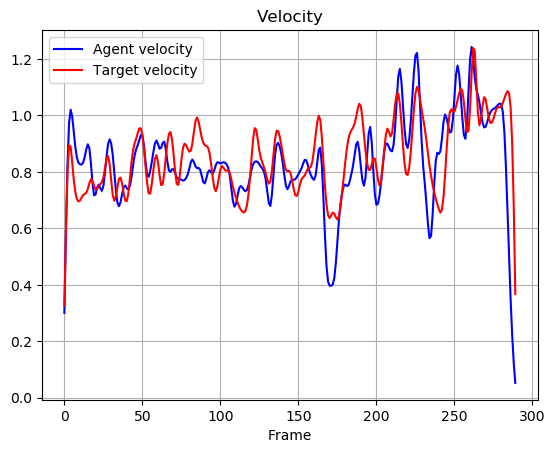

In [17]:
depth_dt = [(depth_time[i]-depth_time[i-1]).to_sec() for i in range(1, len(depth_time))]
depth_dt
plt.plot(depth_dt)
filtered_dt = gaussian_filter1d(depth_dt, sigma=2)
plt.plot(filtered_dt, 'r-')
mean_dt = np.mean(filtered_dt)
print("Mean depth dt:", mean_dt)

# get target and agent velocity

target_velocity = []
agent_velocity = []

for i in range(1, len(refined_x_rot)):
    dt = mean_dt

    dx = refined_x_rot[i] - refined_x_rot[i-1]
    dy = refined_y_rot[i] - refined_y_rot[i-1]
    # dz = refined_x_rot[i][2,3] - refined_x_rot[i-1][2,3]
    dist = np.sqrt(dx**2 + dy**2)
    agent_velocity.append(dist / dt)

    dx_t = target_pose_x_rot[i] - target_pose_x_rot[i-1]
    dy_t = target_pose_y_rot[i] - target_pose_y_rot[i-1]
    # dz_t = target_pose_y_rot[i][2] - target_pose_y_rot[i-1][2]
    dist_t = np.sqrt(dx_t**2 + dy_t**2)
    target_velocity.append(dist_t / dt)

plt.figure()
plt.plot(agent_velocity, 'b-', label='Agent velocity')
plt.plot(target_velocity, 'r-', label='Target velocity')
plt.title("Velocity")
plt.grid()
plt.legend()
# plt.ylim(0, 1.5)
plt.xlabel("Frame")
print("Max agent velocity:", np.max(agent_velocity))
print("Max target velocity:", np.max(target_velocity))

## Save Animation of plot as mp4

In [42]:
%matplotlib qt

import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(3.5,3.5))

# plt.axis('equal')
# plt.xlim(-1, 30)
# plt.ylim(-5, 1)

plt.plot(refined_x_rot[0], refined_y_rot[0], 'bo', markersize=5)
plt.plot(refined_x_rot[-1], refined_y_rot[-1], 'bo', markersize=5)
plt.plot(refined_x_rot[0], refined_y_rot[0], 'o', c='b')

plt.plot(target_pose_x_rot[0], target_pose_y_rot[0], 'ro', markersize=5)
plt.plot(target_pose_x_rot[-1], target_pose_y_rot[-1], 'ro', markersize=5)
plt.text(target_pose_x_rot[0]- 0.5, target_pose_y_rot[0] + 0.3, 'start', fontsize=10)
plt.text(target_pose_x_rot[-1], target_pose_y_rot[-1] - 0.5, 'end', fontsize=10)

plt.scatter(pcl_2d_rot[:,0], pcl_2d_rot[:,1], s=15, c='gray', alpha=1)

ax.set_xlim(-1, 8)
# ax.set_xlabel("x [m]", fontsize=15)
ax.set_ylim(-5, 4)
# ax.set_ylabel("y [m]", fontsize=15)
ax.set_aspect("equal")

target_line, = plt.plot([], [], 'r')
target_arrow = plt.quiver([], [], [], [], scale=8, scale_units='inches', width=0.005, color='r')
ours_line, = plt.plot([], [], 'b')
bearing_line, = plt.plot([], [], 'g', alpha=0.2)


fov = 110 * np.pi / 180 / 2
coord_frame = np.array([[0, 0],
                        [np.cos(fov), -np.sin(fov)],
                        [np.cos(fov), np.sin(fov)]]) * 0.7



yaw_list = []
for i in range(start,len(refined_poses)):
    T_w_o = T_w_c_to_T_w_o(refined_poses[i])
    yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
    yaw_list.append(yaw+angle)

# yaw_list = gaussian_filter1d(yaw_list, sigma=2)
R_w_o = np.array([[np.cos(yaw_list[0]), -np.sin(yaw_list[0])],
                  [np.sin(yaw_list[0]), np.cos(yaw_list[0])]])


ours_view_coord_frame = (R_w_o @ coord_frame.T).T
ours_view_coord_frame = ours_view_coord_frame + np.array([refined_x_rot[0], refined_y_rot[0]])
ours_view_coord_line, = plt.fill(ours_view_coord_frame[:,0], ours_view_coord_frame[:,1], 'k', linewidth=1, fill=False)

accum_length = 0
acuum_length_target = 0
bearing_line_list = []



def update_lines(num):
    # print(num)
    global accum_length, acuum_length_target
    
    target_line.set_data(target_pose_x_rot[:num], target_pose_y_rot[:num])
    ours_line.set_data(refined_x_rot[:num], refined_y_rot[:num])

    R_w_o = np.array([[np.cos(yaw_list[num]), -np.sin(yaw_list[num])],
                      [np.sin(yaw_list[num]), np.cos(yaw_list[num])]])

    ours_view_coord_frame = (R_w_o @ coord_frame.T).T
    ours_view_coord_frame = ours_view_coord_frame + np.array([refined_x_rot[num], refined_y_rot[num]])
    ours_view_coord_line.set_xy(ours_view_coord_frame)

    theta = np.arctan2(target_pose_y_rot[num] - target_pose_y_rot[num-1], target_pose_x_rot[num] - target_pose_x_rot[num-1])
    target_arrow.set_UVC(np.cos(theta), np.sin(theta))
    target_arrow.set_offsets([target_pose_x_rot[num], target_pose_y_rot[num]])

    accum_length += np.sqrt(((refined_x_rot[num] - refined_x_rot[num-1])**2 + (refined_y_rot[num] - refined_y_rot[num-1])**2))
    acuum_length_target += np.sqrt(((target_pose_x_rot[num] - target_pose_x_rot[num-1])**2 + (target_pose_y_rot[num] - target_pose_y_rot[num-1])**2))
    # plot bearing line according to the accumulated length
    if accum_length > 0.7 or num == len(refined_poses)-1 or acuum_length_target > 0.7:
        ax.plot([refined_x_rot[num], target_pose_x_rot[num]], [refined_y_rot[num], target_pose_y_rot[num]], 'g', alpha=0.2)
        # bearing_line_list.append(([cam_pose_ours_tmp[num,0], target_trajectory_tmp[num,0]], 
        #                           [cam_pose_ours_tmp[num,1], target_trajectory_tmp[num,1]]))
        # bearing_line.set_data(*zip(*bearing_line_list))
        accum_length = 0
        acuum_length_target = 0
    
    return target_line, ours_line


ani = animation.FuncAnimation(fig, update_lines, frames=range(1,len(refined_x_rot)), interval=50)
# plt.legend([ours_line, target_line], ['Drone', 'Target'], loc='upper center', bbox_to_anchor=(0.5, 1.20), ncol=4, fontsize=15)
# ani.save('/home/seungwoo/sy-sw-combination/visualization/experiment_visualization/episode_A.mp4', fps=10, dpi=300)



ani.save('3F_plot.mp4', fps=10, dpi=300)
# plt.show()

%matplotlib inline


INFO - 2025-09-26 00:14:44,072 - animation - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO - 2025-09-26 00:14:44,073 - animation - MovieWriter.run: running command: ['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1050x1050', '-pix_fmt', 'rgba', '-r', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', '3F_plot.mp4']


In [52]:
if end - start == len(refined_x_rot) : ### 이게 참이어야 비디오 시퀀스 맞는것!!!!
    # save rgb image as mp4
    import cv2
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter('3F_rgb.mp4', fourcc, 10.0, (640,360))
    for i in range(start, end):
        img = cv2.cvtColor(rgb_list[i], cv2.COLOR_RGB2BGR)
        img = cv2.resize(img, (640,360))
        out.write(img)
    out.release()

In [30]:
# matric for submission
def distance_to_obstacle(x, y, obstacle_points): # 25_a
    if len(obstacle_points) == 0:
        return float('inf')
    distances = np.hypot(obstacle_points[:,0] - x, obstacle_points[:,1] - y)
    return np.min(distances)

def distance_to_target(x, y, x_t, y_t): # 25_b
    return np.hypot(x - x_t, y - y_t)

def distance_between_line_seg_to_obs(x1, y1, x2, y2, obstacle_points): # 26_1
    if len(obstacle_points) == 0:
        return float('inf')
    # line segment vector
    dx = x2 - x1
    dy = y2 - y1
    if dx == 0 and dy == 0:
        return distance_to_obstacle(x1, y1, obstacle_points)
    
    # line segment 길이 제곱
    seg_len_sq = dx * dx + dy * dy

    # 각 장애물 점에 대해
    min_dist = float('inf')
    for (ox, oy, _) in obstacle_points:
        # 선분 위의 투영점 계산 (t는 0~1 사이)
        t = ((ox - x1) * dx + (oy - y1) * dy) / seg_len_sq
        t = max(0, min(1, t))  # 선분 밖으로 나가지 않도록 클램핑

        # 투영점 좌표
        proj_x = x1 + t * dx
        proj_y = y1 + t * dy

        # 장애물 점과 투영점 사이 거리 계산
        dist = np.hypot(ox - proj_x, oy - proj_y)
        if dist < min_dist:
            min_dist = dist

    return min_dist

def absolute_difference_bw_yaw_and_target_direction(x, y, yaw, x_t, y_t): # 26_2
    dir_to_target = np.arctan2(y_t - y, x_t - x)
    diff = yaw - dir_to_target
    # wrap to [-pi, pi]
    while diff > np.pi:
        diff -= 2 * np.pi
    while diff < -np.pi:
        diff += 2 * np.pi
    return abs(diff)

def distance_between_line_seg_to_obs_plot(x1, y1, x2, y2, obstacle_points):
    if len(obstacle_points) == 0:
        return float('inf')
    # line segment vector
    dx = x2 - x1
    dy = y2 - y1
    if dx == 0 and dy == 0:
        return distance_to_obstacle(x1, y1, obstacle_points)
    
    # line segment 길이 제곱
    seg_len_sq = dx * dx + dy * dy

    # 각 장애물 점에 대해
    closet_seg = None
    min_dist = float('inf')
    for (ox, oy, _) in obstacle_points:
        # 선분 위의 투영점 계산 (t는 0~1 사이)
        t = ((ox - x1) * dx + (oy - y1) * dy) / seg_len_sq
        t = max(0, min(1, t))  # 선분 밖으로 나가지 않도록 클램핑

        # 투영점 좌표
        proj_x = x1 + t * dx
        proj_y = y1 + t * dy

        # 장애물 점과 투영점 사이 거리 계산
        dist = np.hypot(ox - proj_x, oy - proj_y)
        if dist < min_dist:
            min_dist = dist
            closet_seg = (proj_x, proj_y, ox, oy)

    return min_dist, closet_seg

In [31]:
dist_from_obs = []
for i in range(len(refined_x)):
    dist = distance_to_obstacle(refined_x[i], refined_y[i], pcl_2d)
    dist_from_obs.append(dist)
    if dist < 0.3:
        print(f"Collision risk at point {i}, distance to obstacle: {dist:.2f} m")

dist_from_target = []
for i in range(len(refined_x)):
    dist = distance_to_target(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i])
    dist_from_target.append(dist)

line_seg_dist_from_obs = []
for i in range(len(refined_x)-1):
    dist = distance_between_line_seg_to_obs(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i], pcl_2d)
    line_seg_dist_from_obs.append(dist)
    if dist < 0.3:
        print(f"Collision risk at segment {i}-{i+1}, distance to obstacle: {dist:.2f} m")

yaw_diff_from_target_dir = []
for i in range(len(refined_x)):
    # yaw is from -y rotation
    T_w_o = T_w_c_to_T_w_o(refined_poses[i+start])
    yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
    diff = absolute_difference_bw_yaw_and_target_direction(refined_x[i], refined_y[i], yaw, target_pose_x[i], target_pose_y[i])
    yaw_diff_from_target_dir.append(diff)



Collision risk at point 185, distance to obstacle: 0.30 m
Collision risk at point 186, distance to obstacle: 0.29 m
Collision risk at segment 181-182, distance to obstacle: 0.29 m
Collision risk at segment 182-183, distance to obstacle: 0.28 m
Collision risk at segment 183-184, distance to obstacle: 0.27 m
Collision risk at segment 184-185, distance to obstacle: 0.27 m
Collision risk at segment 185-186, distance to obstacle: 0.28 m
Collision risk at segment 186-187, distance to obstacle: 0.29 m


Text(0.5, 1.0, 'Absolute Yaw Difference to Target Direction')

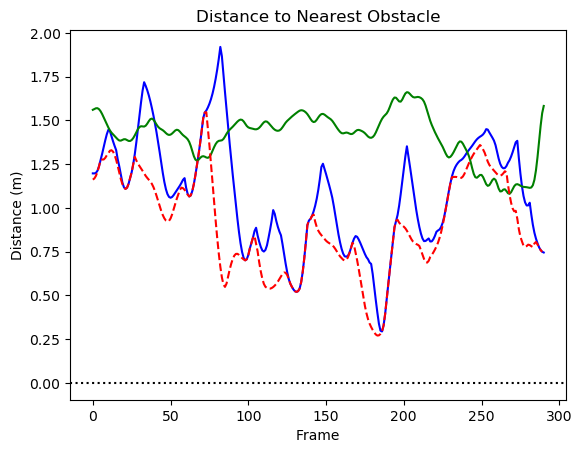

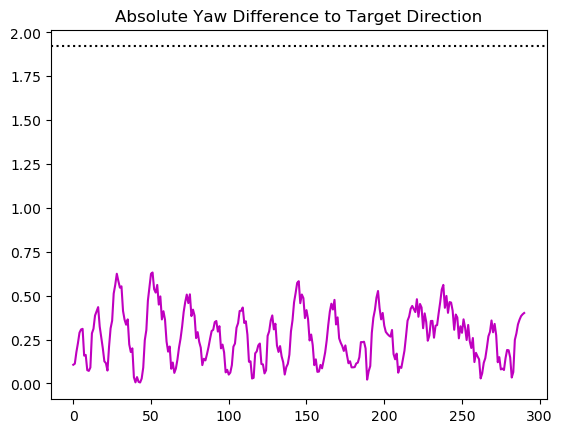

In [32]:
plt.figure()
plt.plot(dist_from_obs, 'b-', label='Distance from robot to nearest obstacle')
plt.plot(dist_from_target, 'g-', label='Distance from robot to target')
plt.plot(line_seg_dist_from_obs, 'r--', label='Distance from path segment to nearest obstacle')
plt.axhline(0.0, color='k', linestyle=':', label='Safety threshold (0.3 m)')
plt.title("Distance to Nearest Obstacle")
plt.xlabel("Frame")
plt.ylabel("Distance (m)")

plt.figure()
plt.plot(yaw_diff_from_target_dir, 'm-')
plt.axhline(np.deg2rad(110), color='k', linestyle=':', label='Safety threshold (110°)')
plt.title("Absolute Yaw Difference to Target Direction")


In [35]:
print("Average, std, min, max distance from robot to nearest obstacle:", np.mean(dist_from_obs), np.std(dist_from_obs), np.min(dist_from_obs), np.max(dist_from_obs))
print("Average, std, min, max distance from robot to target:", np.mean(dist_from_target), np.std(dist_from_target), np.min(dist_from_target), np.max(dist_from_target))
print("Average, std, min, max distance from path segment to nearest obstacle:", np.mean(line_seg_dist_from_obs), np.std(line_seg_dist_from_obs), np.min(line_seg_dist_from_obs), np.max(line_seg_dist_from_obs))
print("Average, std, min, max absolute yaw difference to target direction (deg):", np.rad2deg(np.mean(yaw_diff_from_target_dir)), np.rad2deg(np.std(yaw_diff_from_target_dir)), np.rad2deg(np.min(yaw_diff_from_target_dir)), np.rad2deg(np.max(yaw_diff_from_target_dir)))



Average, std, min, max distance from robot to nearest obstacle: 1.0786688324912261 0.31926451602811234 0.29390009215335866 1.919730429960564
Average, std, min, max distance from robot to target: 1.411192651899159 0.14002708670289926 1.080219855132076 1.6611195345847736
Average, std, min, max distance from path segment to nearest obstacle: 0.9087109753105741 0.281569827846126 0.27063539289878724 1.546386260156075
Average, std, min, max absolute yaw difference to target direction (deg): 15.51530944428883 8.425306213410925 0.32502771005042075 36.225979842348536


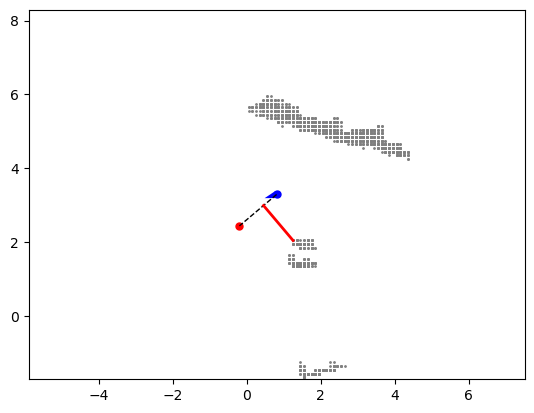

In [33]:

plt.figure()
# plot robot_pose at i
i = len(refined_x) - 50
plt.axis('equal')
plt.xlim(refined_x[i]-5, refined_x[i]+5)
plt.ylim(refined_y[i]-5, refined_y[i]+5)
# plot target_pose at i
plt.plot(target_pose_x[i], target_pose_y[i], 'ro', markersize=5)
# plot robot_pose at i
plt.plot(refined_x[i], refined_y[i], 'bo', markersize=5)
# plot arrow for robot direction

T_w_o = T_w_c_to_T_w_o(refined_poses[i+start])
yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
dir = np.array([np.cos(yaw), np.sin(yaw)])
plt.quiver(refined_x[i], refined_y[i], dir[0], dir[1],
             scale=8, scale_units='inches', width=0.01, color='b')

# plot pcl around robot
valid_indices = np.where(np.hypot(refined_x[i] - pcl_2d[:,0], refined_y[i] - pcl_2d[:,1]) <= 5.0)[0]
clipped_pcl = pcl_2d[valid_indices]
plt.scatter(clipped_pcl[:,0], clipped_pcl[:,1], s=1, c='gray', alpha=1)
# plot line segment from robot to target
plt.plot([refined_x[i], target_pose_x[i]], [refined_y[i], target_pose_y[i]], 'k--', linewidth=1)
# plot closest point between line segment and obstacle
dist, closet_seg = distance_between_line_seg_to_obs_plot(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i], pcl_2d)
if closet_seg is not None:
    plt.plot([closet_seg[0], closet_seg[2]], [closet_seg[1], closet_seg[3]], 'r-', linewidth=2)


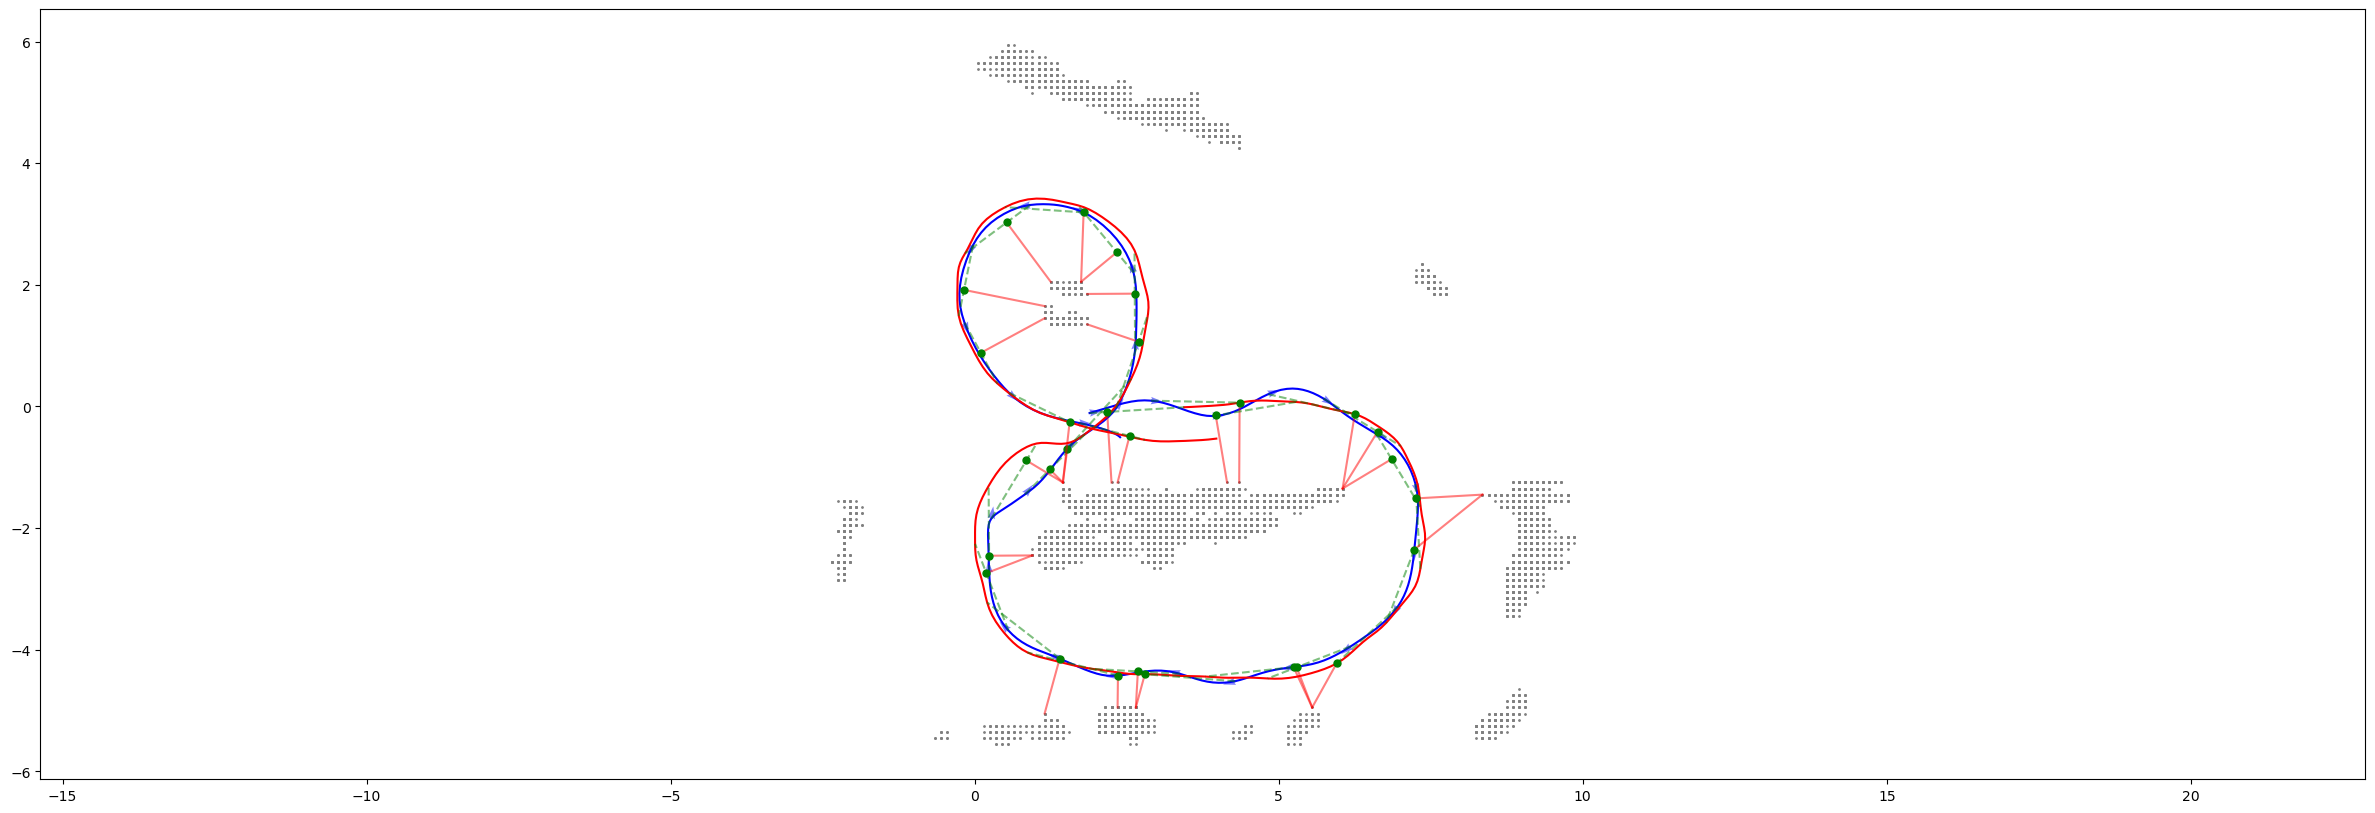

In [34]:
plt.figure(figsize=(30, 10))
plt.axis('equal')
plt.plot(refined_x, refined_y, 'b-', label='Robot')
plt.plot(target_pose_x, target_pose_y, 'r-', markersize=2, label='Target')
# color with height
# z_min = np.min(pcl_2d[:,2])
# z_max = np.max(pcl_2d[:,2])
# color_map = plt.get_cmap('jet')
# colors = color_map((pcl_2d[:,2] - z_min) / (z_max - z_min))
# sc = plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c=colors, alpha=0.5)
plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c='gray', alpha=1)


for i in range(len(refined_x)-1):
    dist, closet_seg = distance_between_line_seg_to_obs_plot(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i], pcl_2d)
    if i % 10 == 0:
        if closet_seg is not None:
            proj_x, proj_y, ox, oy = closet_seg
            plt.plot([refined_x[i], target_pose_x[i]], [refined_y[i], target_pose_y[i]], 'g--', alpha=0.5)
            plt.plot([proj_x, ox], [proj_y, oy], 'r-', alpha=0.5)
            plt.plot(proj_x, proj_y, 'go', markersize=5)

            #plot yaw arrow at robot position
            T_w_o = T_w_c_to_T_w_o(refined_poses[i+start])
            yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
            dir = np.array([np.cos(yaw), np.sin(yaw)])
            plt.quiver(refined_x[i], refined_y[i], dir[0], dir[1],
                        scale=8, scale_units='inches', width=0.005, color='b', alpha=0.5)

### save as rosbag